# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

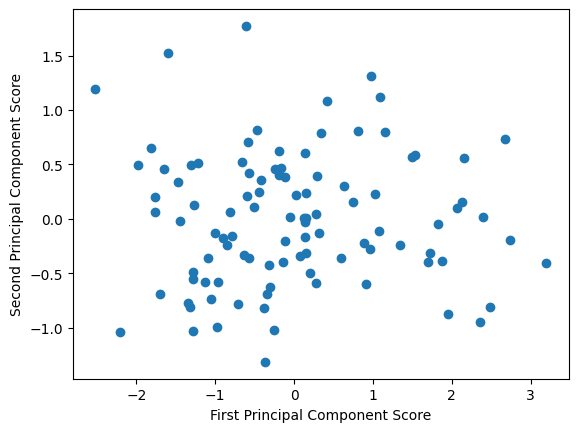

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

For the outliers, PC1 is very low and PC2 is very high. Since PC1 is dominated by series 1 & 2 and PC2 largely consists of series 3, this implies series 3 is well above average for these 3 points.

Becasue series 1 and 2 were generated to be proportional, it can be hard to determine the differences in their contributions.

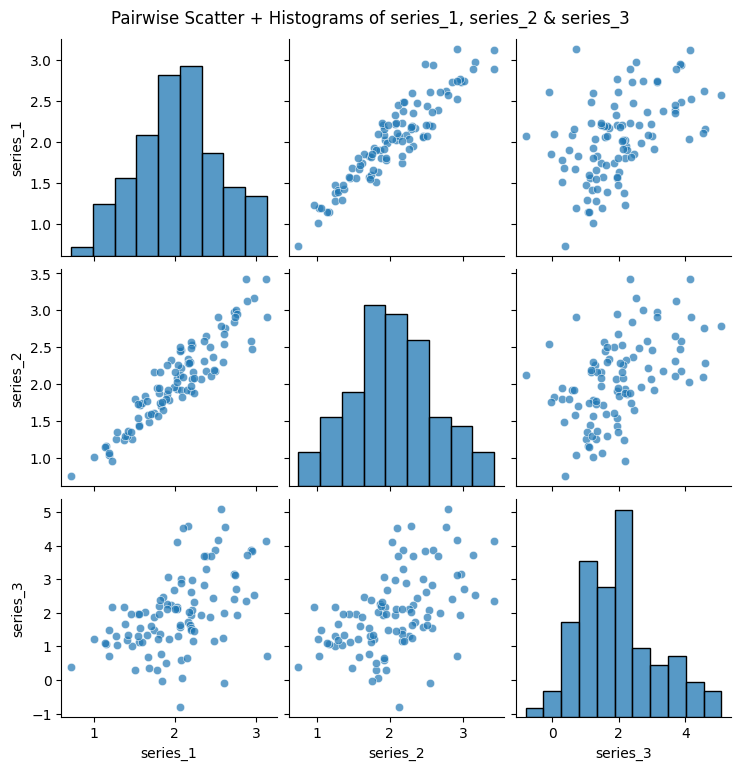

In [2]:

import seaborn as sns


df_raw = pd.DataFrame({
    'series_1': series_1,
    'series_2': series_2,
    'series_3': series_3
})

sns.pairplot(df_raw, diag_kind='hist', plot_kws={'alpha':0.7})
plt.suptitle("Pairwise Scatter + Histograms of series_1, series_2 & series_3", y=1.02)
plt.show()

You can see that series 1 and 2 have a high correlation while series 3 is largely independent of these two. 

The original graph is great for spotting structures in multivariative data but struggles to identify exactly what each series is doing.

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "austinHousingData.csv"


df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ericpierce/austinhousingprices",
  file_path,
  # Provide any additional arguments like 
    pandas_kwargs={"sep": ","}
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/home/codespace/.python/current/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_18647/4082401683.py:7: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  df = kagglehub.load_dataset(


100%|██████████| 3.79M/3.79M [00:00<00:00, 31.1MB/s]

Extracting zip of austinHousingData.csv...


First 5 records:          zpid          city          streetAddress  zipcode  \
0   111373431  pflugerville   14424 Lake Victor Dr    78660   
1   120900430  pflugerville     1104 Strickling Dr    78660   
2  2084491383  pflugerville    1408 Fort Dessau Rd    78660   
3   120901374  pflugerville     1025 Strickling Dr    78660   
4    60134862  pflugerville  15005 Donna Jane Loop    78660   

                                         description   latitude  longitude  \
0  14424 Lake Victor Dr, Pflugerville, TX 78660 i...  30.430632 -97.663078   
1  Absolutely GORGEOUS 4 Bedroom home with 2 full...  30.432673 -97.661697   
2  Under construction - estimated completion in A...  30.409748 -97.639771   
3  Absolutely darling one story home in charming ...  30.432112 -97.661659   
4  Brimming with appeal & warm livability! Sleek ...  30.437368 -97.656860   

   propertyTaxRate  garageSpaces  hasAssociation  ...  numOfMiddleSchools  \
0             1.98             2            True  ...     

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:


Draw heatmaps.



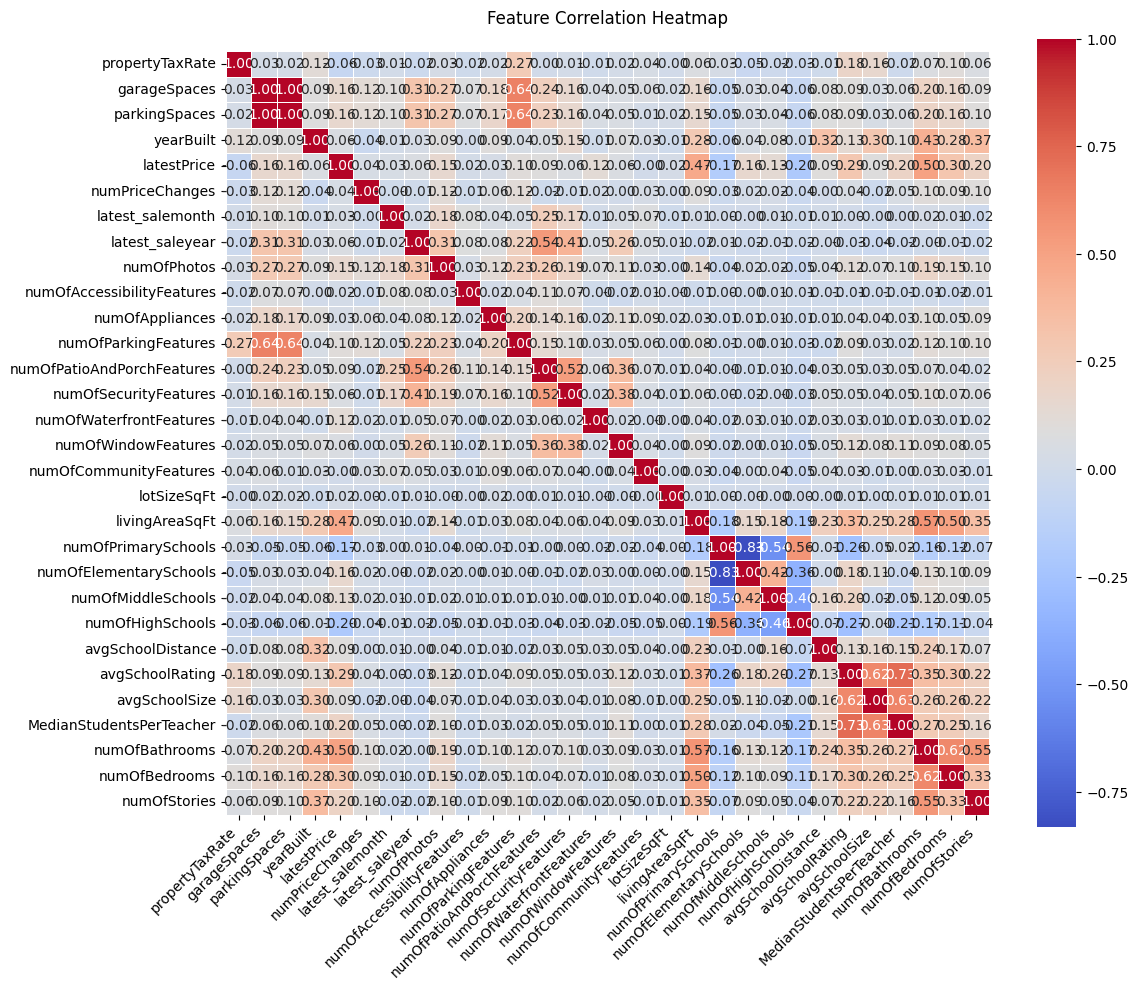

In [6]:
usable_columns = df.select_dtypes(include=['int64', 'float64'])
usable_columns = usable_columns.drop(columns=['zpid','zipcode','latitude','longitude'])

corr = usable_columns.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap="coolwarm",
    square=True
)
plt.title("Feature Correlation Heatmap", pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Draw bubble plots.

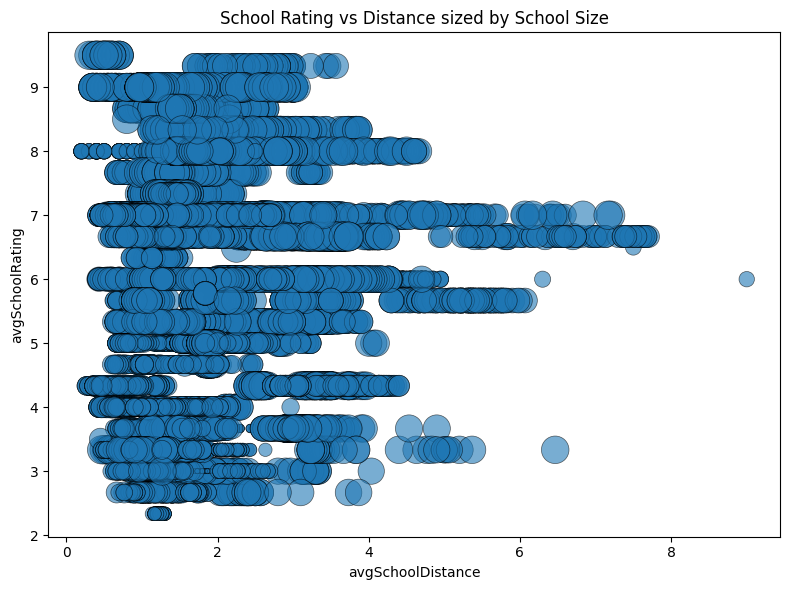

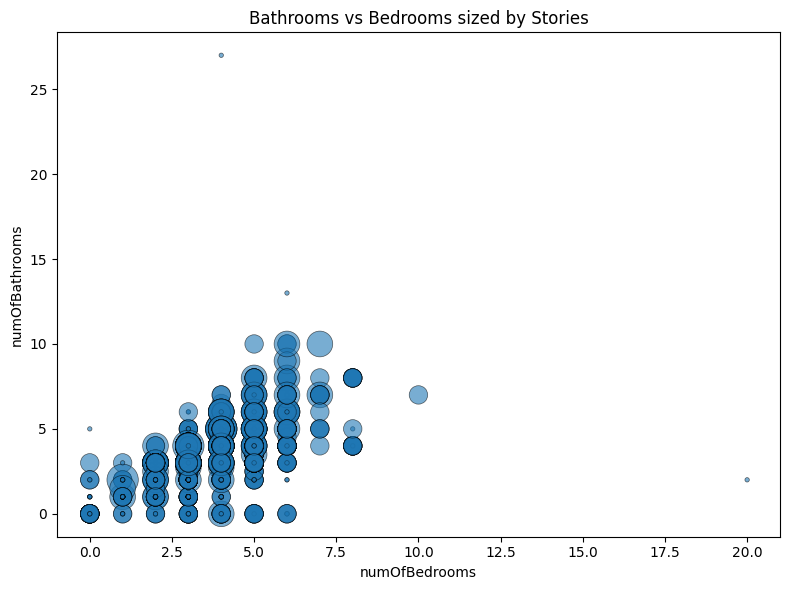

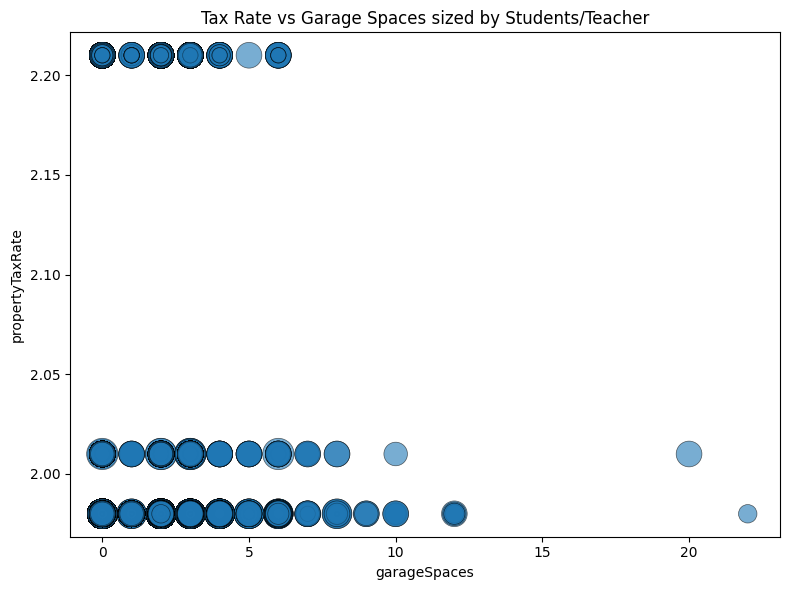

In [ ]:
plot_configs = [
    ('avgSchoolDistance', 'avgSchoolRating', 'avgSchoolSize', 'School Rating vs Distance sized by School Size'),
    ('numOfBedrooms', 'numOfBathrooms', 'numOfStories', 'Bathrooms vs Bedrooms sized by Stories'),
    ('garageSpaces', 'propertyTaxRate', 'MedianStudentsPerTeacher', 'Tax Rate vs Garage Spaces sized by Students/Teacher'),
]

for x, y, size_col, title in plot_configs:
    sizes = (
        (usable_columns[size_col] - usable_columns[size_col].min())
        / (usable_columns[size_col].max() - usable_columns[size_col].min())
        * 500 + 10
    )
    plt.figure(figsize=(8, 6))
    plt.scatter(
        usable_columns[x],
        usable_columns[y],
        s=sizes,
        alpha=0.6,
        edgecolors='k',
        linewidth=0.5
    )
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.tight_layout()
    plt.show()


Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?


PC2 is almost entirely sale price
PC1 is every other variable and captures nearly all of the variation
PC3 is noise

Overall this isn't that useful as every variable is acting on different scales

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca.fit(usable_columns)


components = pd.DataFrame(
    pca.components_,
    index=['PC1','PC2','PC3'],
    columns=usable_columns.columns
)
print("Principal component vectors:\n", components, "\n")
print("Explained variance ratios:", pca.explained_variance_ratio_)

Principal component vectors:
      propertyTaxRate  garageSpaces  parkingSpaces     yearBuilt  latestPrice  \
PC1    -8.611543e-12  2.515701e-09   2.518221e-09 -2.155450e-08     0.000776   
PC2    -7.284145e-09  4.685249e-07   4.668486e-07  2.855918e-06     0.999999   
PC3     4.610036e-06  1.026637e-04   1.013215e-04  5.183587e-03    -0.001422   

     numPriceChanges  latest_salemonth  latest_saleyear   numOfPhotos  \
PC1     1.186366e-11     -3.090834e-09     6.213500e-10 -5.194980e-09   
PC2     2.103328e-07      2.372311e-07     1.073521e-07  7.218405e-06   
PC3     1.601456e-04     -4.352074e-06    -4.029227e-05  1.349989e-03   

     numOfAccessibilityFeatures  ...  numOfElementarySchools  \
PC1               -9.230558e-12  ...           -3.200821e-11   
PC2                6.450223e-09  ...            8.092035e-08   
PC3               -3.038767e-06  ...            1.793052e-05   

     numOfMiddleSchools  numOfHighSchools  avgSchoolDistance  avgSchoolRating  \
PC1       -1.67364


Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

df_num = usable_columns.copy()

multi_results = []
for target in df_num.columns:
    X = df_num.drop(columns=target)
    y = df_num[target]
    model = LinearRegression()

    scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    multi_results.append({
        'target': target,
        'R2_mean': np.mean(scores),
        'R2_std': np.std(scores)
    })
multi_df = pd.DataFrame(multi_results).sort_values('R2_mean', ascending=False)
print("Predictability of each feature from *all* others:\n", multi_df)


pair_results = []
for target in df_num.columns:
    for feat in df_num.columns.drop(target):
        X = df_num[[feat]]
        y = df_num[target]
        scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2', n_jobs=-1)
        pair_results.append({
            'predictor': feat,
            'target': target,
            'R2_mean': np.mean(scores)
        })
pair_df = pd.DataFrame(pair_results)

top_pairs = pair_df.sort_values('R2_mean', ascending=False).head(10)
print("\nTop 10 single‑feature → target pairs by R²:\n", top_pairs)


Predictability of each feature from *all* others:
                         target       R2_mean        R2_std
1                 garageSpaces  9.965783e-01  9.818939e-04
2                parkingSpaces  9.965525e-01  1.003385e-03
27              numOfBathrooms  5.398442e-01  1.523779e-01
24             avgSchoolRating  5.363560e-01  2.322877e-01
18              livingAreaSqFt  5.280516e-01  2.130652e-01
26    MedianStudentsPerTeacher  4.474467e-01  1.961126e-01
11        numOfParkingFeatures  4.285697e-01  1.618136e-01
12  numOfPatioAndPorchFeatures  3.595513e-01  1.921737e-01
19         numOfPrimarySchools  3.400592e-01  3.191914e-01
13       numOfSecurityFeatures  3.343503e-01  3.999223e-02
7              latest_saleyear  3.020456e-01  1.951481e-01
29                numOfStories  3.000245e-01  1.095016e-01
8                  numOfPhotos  1.229504e-01  1.281139e-01
16      numOfCommunityFeatures  1.219086e-01  4.268683e-01
4                  latestPrice  1.190821e-01  2.098730e-01
15   

In [23]:
df_num = df_num.drop(columns=['numOfStories'])

results = []
for feat in df_num.columns.drop('latestPrice'):
    X = df_num[[feat]]
    scores = cross_val_score(
        LinearRegression(), 
        X, 
        y, 
        cv=5, 
        scoring='r2', 
        n_jobs=-1
    )
    results.append({
        'feature': feat,
        'r2_mean': np.mean(scores)
    })

res_df = pd.DataFrame(results).sort_values('r2_mean', ascending=False)
print("Top 5 features for predicting latestPrice:")
print(res_df.head(5))

Top 5 features for predicting latestPrice:
            feature   r2_mean
26   numOfBathrooms  0.276302
3         yearBuilt  0.112691
27    numOfBedrooms  0.086443
23  avgSchoolRating  0.028520
24    avgSchoolSize  0.027836



Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

Yes the data is what I would expect, especially given the analysis I have already done. It is likely to be very useful for my calculator project.

There are a few outliers, see the above bed/bath/stories plot for a couple.

The PCA was not great just using week 8's methods. Next time I will scale the data.


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

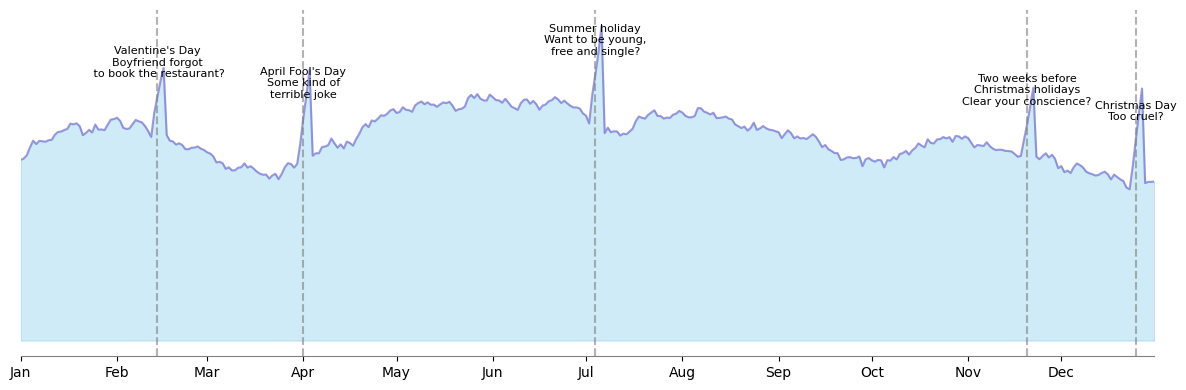

In [25]:
import matplotlib.dates as mdates

dates = pd.date_range('2020-01-01', '2020-12-31', freq='D')
np.random.seed(0)
values = np.random.normal(0, 1, len(dates)).cumsum() + 50

for spike_date, height in [
    ('2020-02-14', 20),  # Valentine’s Day
    ('2020-04-01', 25),  # April Fool’s
    ('2020-07-04', 30),  # Summer holiday
    ('2020-11-20', 22),  # Christmas prep
    ('2020-12-25', 28),  # Christmas Day
]:
    idx = dates.get_loc(pd.to_datetime(spike_date))
    values[idx-2:idx+3] += np.linspace(0, height, 5)

df = pd.DataFrame({'date': dates, 'value': values})

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(df['date'], df['value'], color='skyblue', alpha=0.4)
ax.plot(df['date'], df['value'], color='Slateblue', alpha=0.6, linewidth=1.5)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(df['date'].min(), df['date'].max())
ax.set_yticks([])

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('gray')

annotations = {
    '2020-02-14': "Valentine's Day\nBoyfriend forgot\n to book the restaurant?",
    '2020-04-01': "April Fool's Day\nSome kind of\nterrible joke",
    '2020-07-04': "Summer holiday\nWant to be young,\nfree and single?",
    '2020-11-20': "Two weeks before\nChristmas holidays\nClear your conscience?",
    '2020-12-25': "Christmas Day\nToo cruel?"
}

for date_str, label in annotations.items():
    d = pd.to_datetime(date_str)
    y = df.loc[df['date'] == d, 'value'].values[0] + 5
    ax.axvline(d, color='gray', linestyle='--', alpha=0.6)
    ax.text(d, y, label, ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()